Rewriting and consolidating the looped data runs and plotting functions. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import pandas as pd
import seaborn as sns
import pickle


Working with loop test v2 - adjusted the leak parameters and modeled out the super emitter events as episodic; re-running the 1, 2, 5 kg/hr thresholds; plotting up. 

In [ ]:
#Set up the path for the FEAST output from the loops: 
path_to_loop_results  = 'run_results_loop_test_v2/'
subfolders = [subfold for subfold in os.listdir(path_to_loop_results)]

#Then create the dataframe to catch the output summary data from the runs: 
looped_results = pd.DataFrame(columns = ['program', 'val_avg', 'val_var', 'val_sum','threshold', 'cadence', 'cadence_days'])
counter = -1

#pull the indexs for the last year of data: 
indx_high = 5*365
indx_low = (5*365) - 364

#Conversion factors: 
secPerDay = 60*60*24
gramPerKg = 1000
kgPerUSton = 907.185
nsites = 20

for indx in range(len(subfolders)):

    #split out the info we need from the folder names: 
    split_folder_name = subfolders[indx].split('_')
    threshold = int(split_folder_name[1])
    cadence = split_folder_name[3]
    cadence_days = int(split_folder_name[4])

    #Once you have that subfolder info, pull out the json files within that subfolder: 
    path_to_json = path_to_loop_results + subfolders[indx] + '/'
    json_files = [pos_json for pos_json in os.listdir(path_to_json) if pos_json.endswith('.json')]

    for i in range(len(json_files)):
        read_file = path_to_json + str(json_files[i])
        df = json.load(open(read_file))

        
        #okay - individual file loaded; lets loop through each file and grab the average emissions for each LDAR program. 
        for j in df.keys():
            if j.lower() == "time": #skip the time object
                break
            
            #Calculate the average emissions value and varainace for the full time series for each LDAR Program: 
            avg_em = np.mean(np.array(df[j]['emission timeseries'][indx_low:indx_high])) 
            var_em = np.var(np.array(df[j]['emission timeseries'][indx_low:indx_high])) 
            sum_em = np.sum(np.array(df[j]['emission timeseries'][indx_low:indx_high])) *(secPerDay/gramPerKg/kgPerUSton/nsites*365)

            #Step up the counter: 
            counter += 1 

            #write to location: Not elegent, but I was frustrated with the more sophisticated solutions, 
            # a better python-ist can fix this :) 
            looped_results.at[counter, 'program'] = j
            looped_results.at[counter, 'val_avg'] = avg_em
            looped_results.at[counter, 'val_var'] = var_em
            looped_results.at[counter, 'val_sum'] = sum_em
            looped_results.at[counter, 'threshold'] = threshold
            looped_results.at[counter, 'cadence'] = cadence
            looped_results.at[counter, 'cadence_days'] = cadence_days


# Change the catagorical columns to catagory and re-order: 

looped_results['program'] = looped_results['program'].astype('category')
looped_results['cadence'] = looped_results['cadence'].astype('category')       

reordered = ['monthly', 'bimonthly', 'quarterly', 'semiannual', 'annual']
looped_results['cadence'] = looped_results['cadence'].cat.reorder_categories(reordered, ordered = True)

reordered_programs = ['quarterly_ogi', 'periodic', 'periodic_annual', 'satellite', 'satellite_annual', 'Null']
looped_results['program'] = looped_results['program'].cat.reorder_categories(reordered_programs, ordered = True)

First plot: 5kg threshold, with emission rate in g/s: 

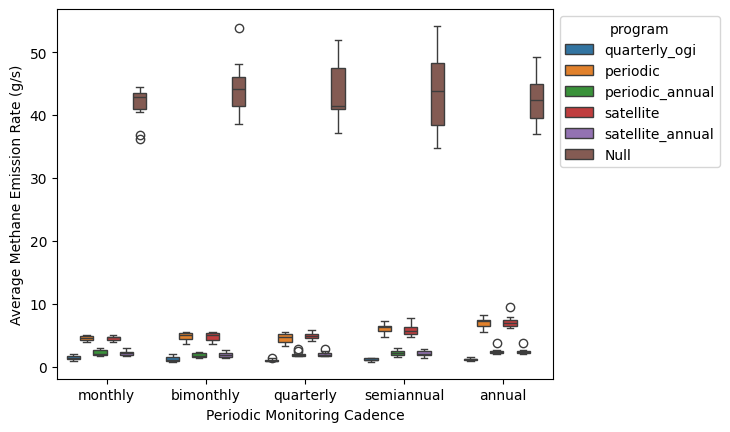

In [6]:
ax = sns.boxplot(data = looped_results[looped_results['threshold'] == 5], x = 'cadence', y = 'val_avg', hue = 'program')
ax.set(xlabel='Periodic Monitoring Cadence', ylabel='Average Methane Emission Rate (g/s)')
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1,1))


Next plot: Same thing but with sum emissions

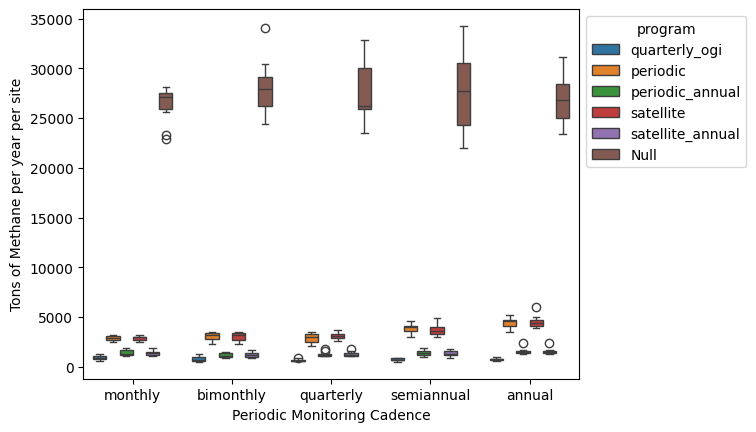

In [7]:
ax = sns.boxplot(data = looped_results[looped_results['threshold'] == 5], x = 'cadence', y = 'val_sum', hue = 'program')
ax.set(xlabel='Periodic Monitoring Cadence', ylabel='Tons of Methane per year per site')
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1,1))

Facet out the plots by threshold; 

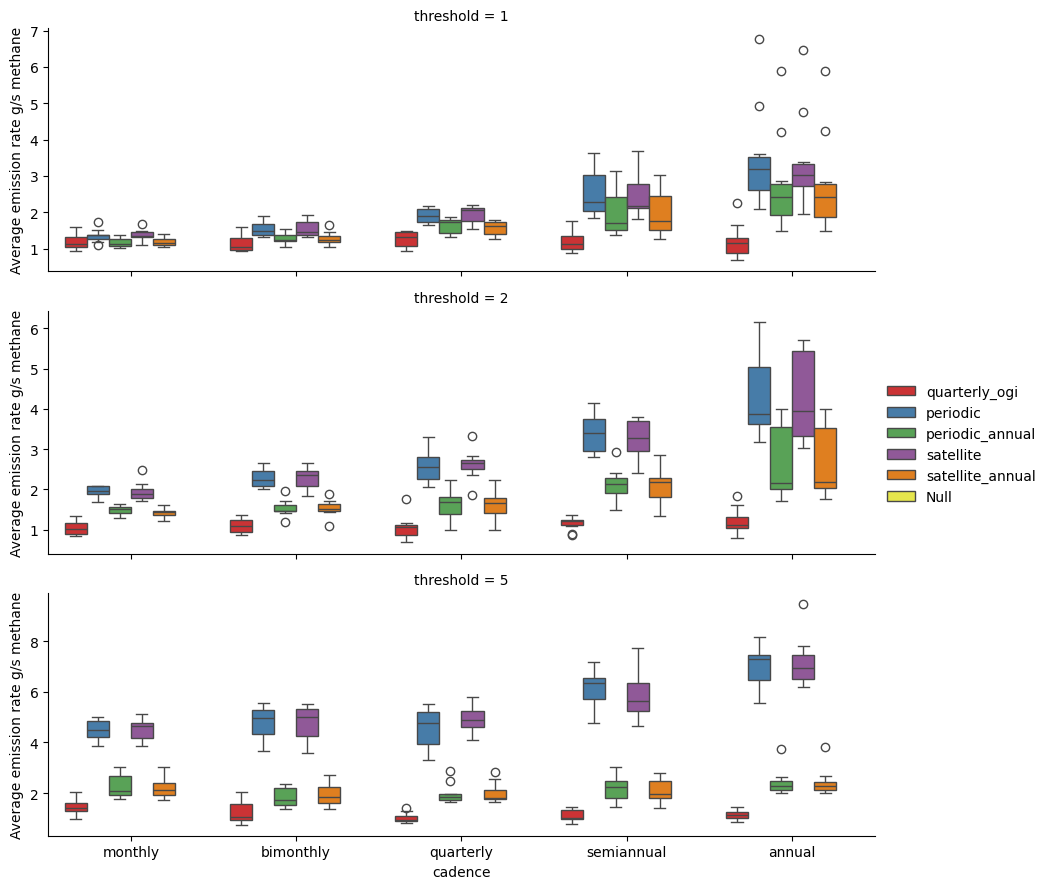

In [18]:
g = sns.FacetGrid(looped_results[looped_results['program'] != 'Null'], row = "threshold",  aspect = 3, height =3, sharey=False)
g.map_dataframe(sns.boxplot,  x = 'cadence', y = 'val_avg',  hue = 'program',palette='Set1' ).add_legend().set(ylabel='Average emission rate g/s methane')


Same thing as the sum: 

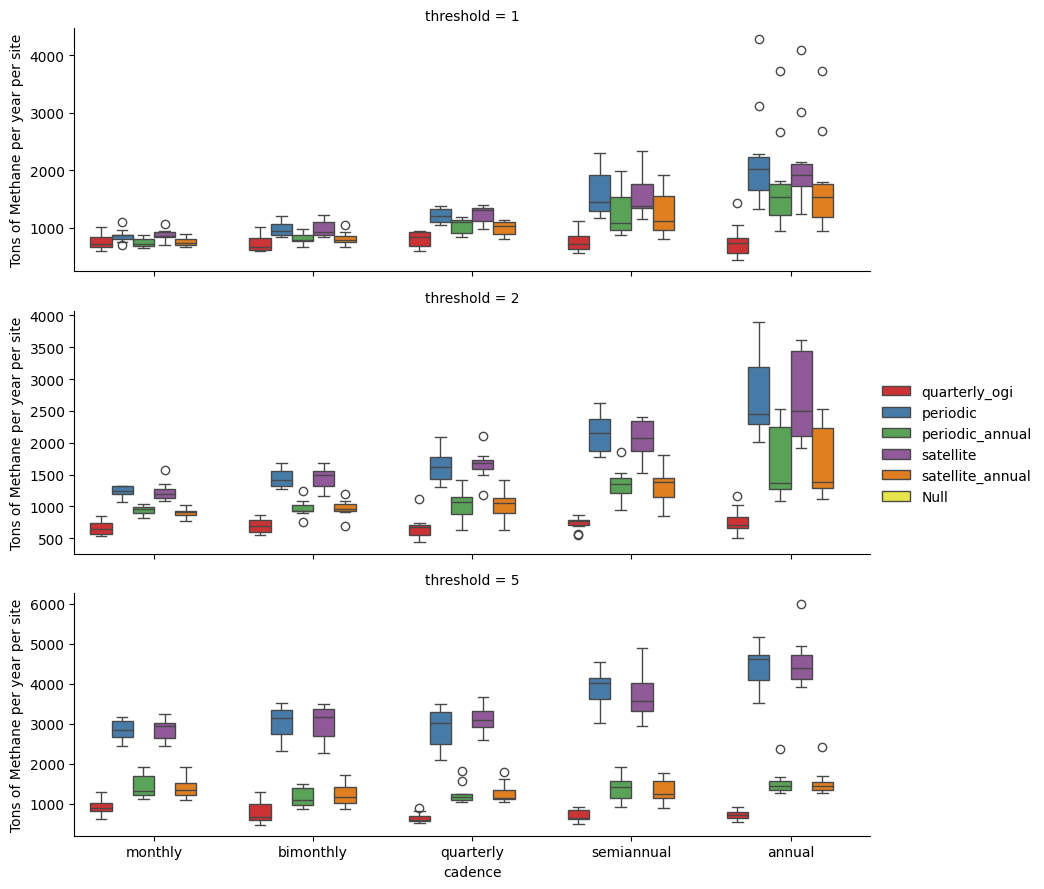

In [19]:
g = sns.FacetGrid(looped_results[looped_results['program'] != 'Null'], row = "threshold",  aspect = 3, height =3, sharey= False)
g.map_dataframe(sns.boxplot,  x = 'cadence', y = 'val_sum',  hue = 'program',palette='Set1' ).add_legend().set(ylabel='Tons of Methane per year per site')

Cool, alright. Lets try something else here...lets look at differences from  quarterly OGI. We need to start this with a summary function to get averages of the programs...lets try with groupby http://stackoverflow.com/questions/29314424/pandas-using-groupby-to-get-mean-for-each-data-category. Ah, we needed reset_index! https://stackoverflow.com/questions/31569549/how-to-groupby-a-dataframe-in-pandas-and-keep-columns

In [20]:
check = looped_results.groupby(['program','cadence', 'threshold'])['val_sum'].mean().reset_index()
# print(check)

C:\Users\hhallida\AppData\Local\Temp\ipykernel_52704\3132363613.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  check = looped_results.groupby(['program','cadence', 'threshold'])['val_sum'].mean().reset_index()


https://stackoverflow.com/questions/22591174/pandas-multiple-conditions-while-indexing-data-frame-unexpected-behavior\

In [22]:
#hmhmhmhmhmh....okay lets see here, how do we want to do this...
quartogi = check[check['program'] == "quarterly_ogi"]
programs = check[check['program'] != "quarterly_ogi"]

ratioed_results = pd.DataFrame(columns = ['program', 'val', 'threshold', 'cadence'])
counter = -1

for i in range(len(programs)):

    #for each index pull the cadence and threshold: 
    cad = programs.iloc[i, programs.columns.get_loc('cadence')]
    thrs = programs.iloc[i, programs.columns.get_loc('threshold')]
    #Then use those to pull the quarterly OGI row: 
    grab = quartogi[(quartogi['cadence'] == cad) & (quartogi['threshold'] == thrs)]
    #once you have that, calculate the difference (or ratio?): 
    val = pd.to_numeric(programs.iloc[i, programs.columns.get_loc('val_sum')]) - pd.to_numeric(grab['val_sum'].values[0])

    #writeout: 
    counter += 1
    ratioed_results.at[counter, 'program'] = programs.iloc[i, programs.columns.get_loc('program')]
    ratioed_results.at[counter, 'threshold'] = thrs
    ratioed_results.at[counter, 'cadence'] = cad
    ratioed_results.at[counter, 'val'] = val
    #
    

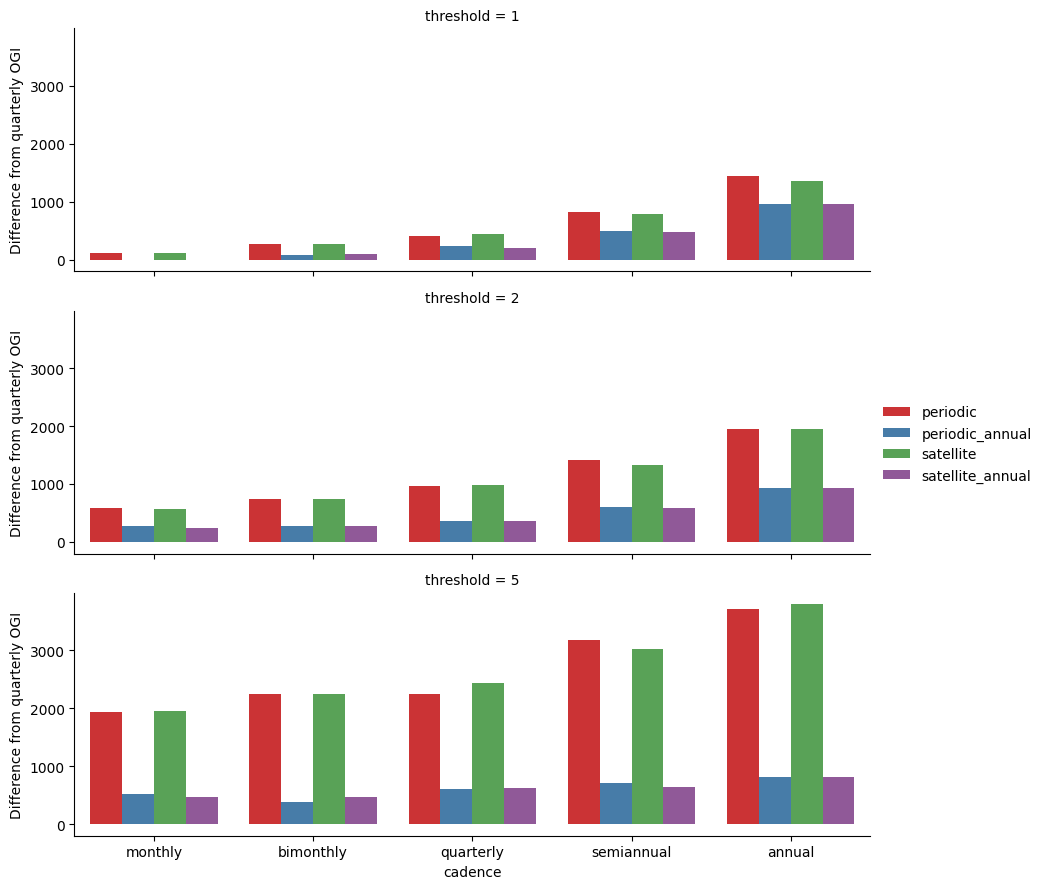

In [23]:
g = sns.FacetGrid(ratioed_results[ratioed_results['program'] != 'Null'], row = "threshold",  aspect = 3, height =3, )
g.map_dataframe(sns.barplot,  x = 'cadence', y = 'val',  hue = 'program',palette='Set1' ).add_legend().set(ylabel='Difference from quarterly OGI')


# ax = sns.barplot(data = ratioed_results[ratioed_results['threshold'] == 5], x = 'cadence', y = 'val', hue = 'program')


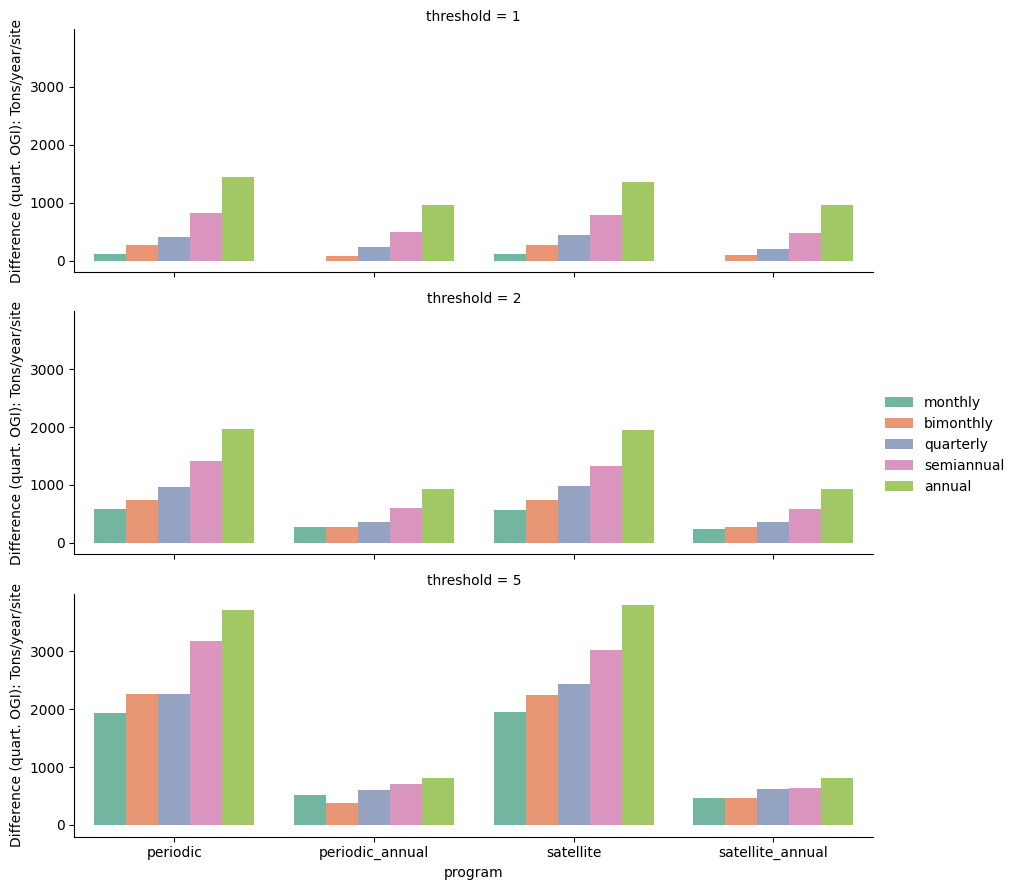

In [15]:
g = sns.FacetGrid(ratioed_results[ratioed_results['program'] != 'Null'], row = "threshold",  aspect = 3, height =3, )
g.map_dataframe(sns.barplot,  x = 'program', y = 'val',  hue = 'cadence',palette='Set2' ).add_legend().set(ylabel='Difference (quart. OGI): Tons/year/site')


Alright. So that's the runs with the adjusted parameters including the periodic emissions for the super emitters; all that's fine. Lets pull up the notevbook that we got back from UT and see if we can understand what's going on in there, plotting wise. 

In [38]:
data = pd.read_pickle(f'run_results_loop_test_v2/Loop_1_kg_annual_365/realization0_emissionsDataFrame.p')
print(data)

         flux  site_index  comp_index  reparable     end_time  repair_cost  \
1    0.011513         0.0       172.0       True          inf         30.0   
2    0.076781        16.0       422.0       True          inf         30.0   
3    0.005172        13.0       158.0       True          inf         30.0   
4    0.001600        10.0       254.0       True          inf        200.0   
5    0.000221        15.0       603.0       True          inf       2000.0   
..        ...         ...         ...        ...          ...          ...   
870  0.002586         9.0       616.0      False  1320.811206          0.0   
871  0.032358        17.0       616.0      False  1390.382321          0.0   
872  0.006250         7.0       616.0      False  1252.329985          0.0   
873  0.006101         4.0       616.0      False   641.586779          0.0   
874  0.000546        13.0       616.0      False   807.313131          0.0   

      start_time  
1       0.000000  
2       0.000000  
3     

Okay, the way that they're calling data out of the pickle files doesn'tmake sense to me; but I'm also seeing something funky in the emissions.p datafiles; I'm wondering if the episodic emissions are acutally set as not-repairable. hmmm....Lets do a plot of that same run...

Hey, are the periodic version of the super emitters set to non repairable? yes. yes they are. 

In [42]:
data2 = pd.read_pickle(f'run_results_loop_test/Loop_1_kg_annual_365/realization0_emissionsDataFrame.p')
print(data2)

         flux  site_index  comp_index  reparable  end_time  repair_cost  \
1    0.009728         6.0       358.0       True       inf         30.0   
2    0.012931         6.0       541.0       True       inf        200.0   
3    0.146016         3.0       263.0       True       inf         20.0   
4    0.062069         6.0       298.0       True       inf       2000.0   
5    0.001456         3.0        75.0       True       inf        500.0   
..        ...         ...         ...        ...       ...          ...   
381  0.007759         6.0       617.0       True       inf        200.0   
382  0.003580        12.0       617.0       True       inf         30.0   
383  0.181632        11.0       617.0       True       inf         20.0   
384  0.069482         6.0       616.0       True       inf         30.0   
385  0.000547        11.0       617.0       True       inf         20.0   

     start_time  
1      0.000000  
2      0.000000  
3      0.000000  
4      0.000000  
5      0.

In [2]:
# The color set defined here is the Tableau 10 color set.
color_set = np.array([
    [78, 121, 167],
    [242, 142,  43],
    [225,  87,  89],
    [118, 183, 178],
    [89, 161,  79],
    [237, 201, 72],
    [176, 122, 161],
    [255, 157, 167],
    [156, 117,  95],
    [186, 176, 172]
]) /255


In [81]:
import json
with open('run_results_loop_test_v2/Loop_5_kg_annual_365/realization0.json') as f:
    runresults = json.load(f)

quarterly_ogi
periodic
periodic_annual
satellite
satellite_annual
no LDAR


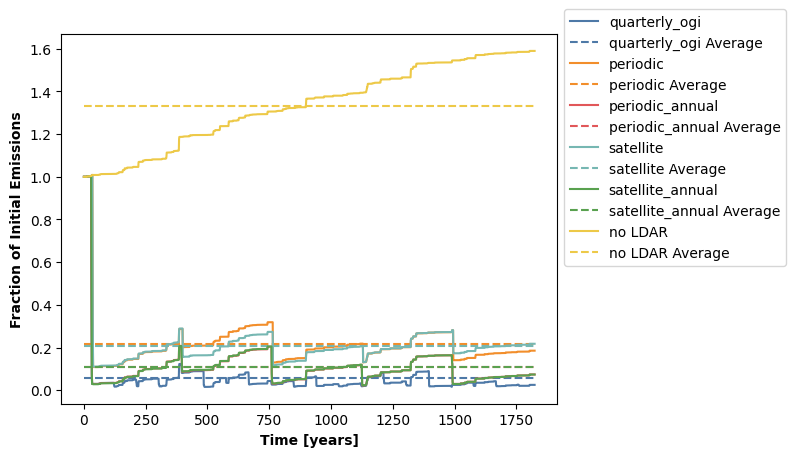

In [82]:
fig = plt.figure()
ax = fig.add_subplot(111)
counter = -1
 
for i in runresults.keys():
    lab = i #set the legend 
    #skip time and also set null to no LDAR
    if i.lower() == "null":
        lab = "no LDAR"
    if i.lower() == "time":
        break
    counter += 1
    print(lab)
    ax.plot(np.array(range(0,runresults['time']['n_timesteps'])), 
            np.array(runresults[i]['emission timeseries']) / runresults["Null"]['emission timeseries'][0], 
            label=lab, color=color_set[counter])
    
    avg_emissions = np.mean(np.array(runresults[i]['emission timeseries'])  / runresults["Null"]['emission timeseries'][0])
    ax.plot([0,runresults['time']['n_timesteps']],np.array([avg_emissions, avg_emissions]), '--', label = lab + ' Average', color = color_set[counter])


plt.xlabel('Time [years]', fontweight = 'bold')
plt.ylabel('Fraction of Initial Emissions', fontweight = 'bold')
plt.legend(loc = 'center left', bbox_to_anchor=(1, 0.72))


Corrected the distributions to be the /actual/ distributions, and not just fugitives all the way down. 

In [2]:
import json
with open('run_results_loop_test_corrected_distributions/Loop_5_kg_monthly_30/realization8.json') as f:
    runresults = json.load(f)

quarterly_ogi
periodic
periodic_annual
satellite
satellite_annual
no LDAR


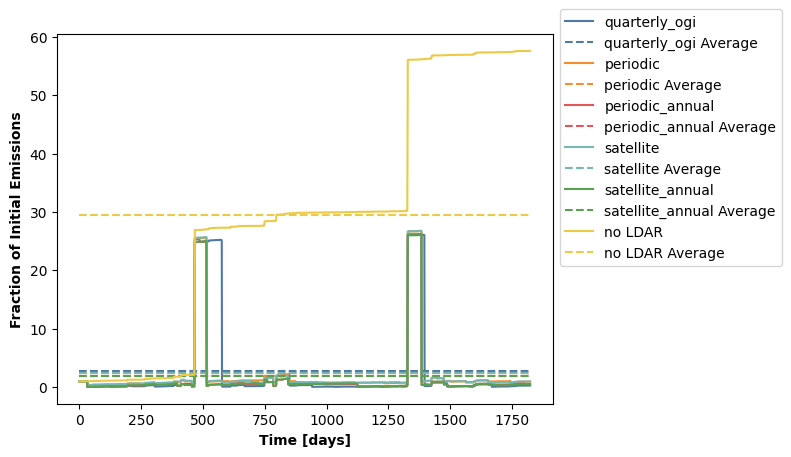

In [5]:
fig = plt.figure()
ax = fig.add_subplot(111)
counter = -1
 
for i in runresults.keys():
    lab = i #set the legend 
    #skip time and also set null to no LDAR
    if i.lower() == "null":
        lab = "no LDAR"
    if i.lower() == "time":
        break
    counter += 1
    print(lab)
    ax.plot(np.array(range(0,runresults['time']['n_timesteps'])), 
            np.array(runresults[i]['emission timeseries']) / runresults["Null"]['emission timeseries'][0], 
            label=lab, color=color_set[counter])
    
    avg_emissions = np.mean(np.array(runresults[i]['emission timeseries'])  / runresults["Null"]['emission timeseries'][0])
    ax.plot([0,runresults['time']['n_timesteps']],np.array([avg_emissions, avg_emissions]), '--', label = lab + ' Average', color = color_set[counter])


plt.xlabel('Time [days]', fontweight = 'bold')
plt.ylabel('Fraction of Initial Emissions', fontweight = 'bold')
plt.legend(loc = 'center left', bbox_to_anchor=(1, 0.72))

In [16]:
#Set up the path for the FEAST output from the loops: 
path_to_loop_results  = 'run_results_loop_test_corrected_distributions/'
subfolders = [subfold for subfold in os.listdir(path_to_loop_results)]

#Then create the dataframe to catch the output summary data from the runs: 
looped_results = pd.DataFrame(columns = ['program', 'val_avg', 'val_var', 'val_sum','threshold', 'cadence', 'cadence_days'])
counter = -1

#pull the indexs for the last year of data: 
indx_high = 5*365
indx_low = (5*365) - 364

#Conversion factors: 
secPerDay = 60*60*24
gramPerKg = 1000
kgPerUSton = 907.185
nsites = 20

for indx in range(len(subfolders)):

    #split out the info we need from the folder names: 
    split_folder_name = subfolders[indx].split('_')
    threshold = int(split_folder_name[1])
    cadence = split_folder_name[3]
    cadence_days = int(split_folder_name[4])

    #Once you have that subfolder info, pull out the json files within that subfolder: 
    path_to_json = path_to_loop_results + subfolders[indx] + '/'
    json_files = [pos_json for pos_json in os.listdir(path_to_json) if pos_json.endswith('.json')]

    for i in range(len(json_files)):
        read_file = path_to_json + str(json_files[i])
        df = json.load(open(read_file))

        
        #okay - individual file loaded; lets loop through each file and grab the average emissions for each LDAR program. 
        for j in df.keys():
            if j.lower() == "time": #skip the time object
                break
            
            #Calculate the average emissions value and varainace for the full time series for each LDAR Program: 
            avg_em = np.mean(np.array(df[j]['emission timeseries'][indx_low:indx_high])) 
            var_em = np.var(np.array(df[j]['emission timeseries'][indx_low:indx_high])) 
            sum_em = np.sum(np.array(df[j]['emission timeseries'][indx_low:indx_high])) *(secPerDay/gramPerKg/kgPerUSton/nsites)

            #Step up the counter: 
            counter += 1 

            #write to location: Not elegent, but I was frustrated with the more sophisticated solutions, 
            # a better python-ist can fix this :) 
            looped_results.at[counter, 'program'] = j
            looped_results.at[counter, 'val_avg'] = avg_em
            looped_results.at[counter, 'val_var'] = var_em
            looped_results.at[counter, 'val_sum'] = sum_em
            looped_results.at[counter, 'threshold'] = threshold
            looped_results.at[counter, 'cadence'] = cadence
            looped_results.at[counter, 'cadence_days'] = cadence_days


# Change the catagorical columns to catagory and re-order: 

looped_results['program'] = looped_results['program'].astype('category')
looped_results['cadence'] = looped_results['cadence'].astype('category')       

reordered = ['monthly', 'bimonthly', 'quarterly', 'semiannual', 'annual']
looped_results['cadence'] = looped_results['cadence'].cat.reorder_categories(reordered, ordered = True)

reordered_programs = ['quarterly_ogi', 'periodic', 'periodic_annual', 'satellite', 'satellite_annual', 'Null']
looped_results['program'] = looped_results['program'].cat.reorder_categories(reordered_programs, ordered = True)

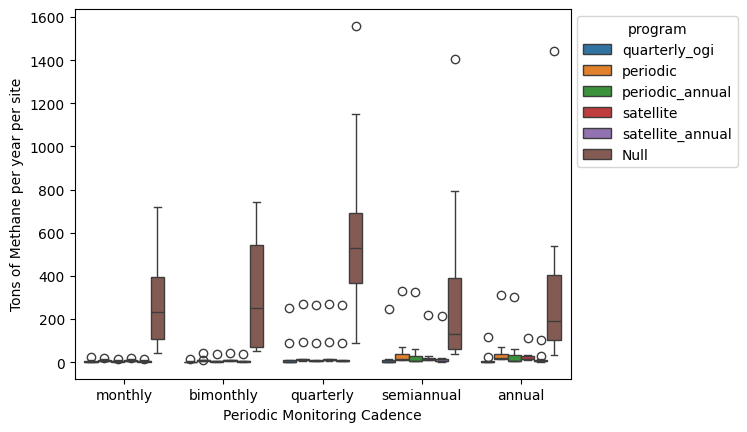

In [17]:
ax = sns.boxplot(data = looped_results[looped_results['threshold'] == 5], x = 'cadence', y = 'val_sum', hue = 'program')
ax.set(xlabel='Periodic Monitoring Cadence', ylabel='Tons of Methane per year per site')
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1,1))

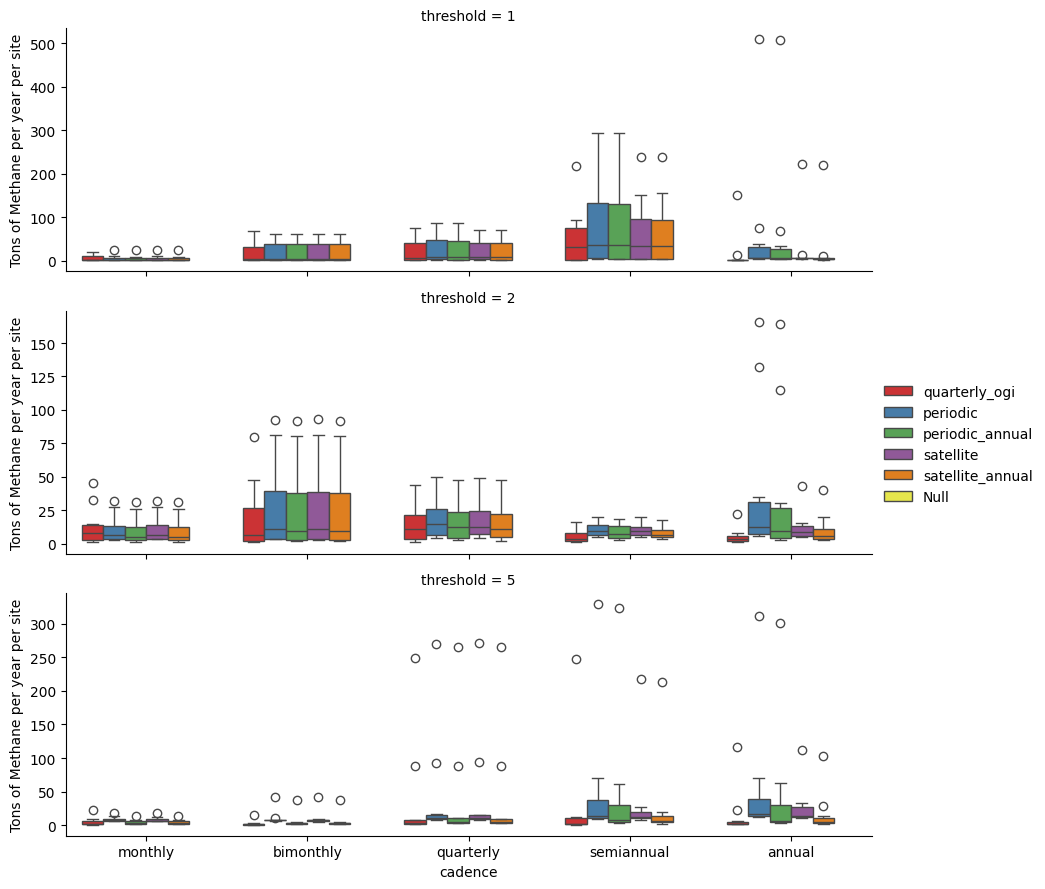

In [23]:
g = sns.FacetGrid(looped_results[looped_results['program'] != 'Null'], row = "threshold",  aspect = 3, height =3, sharey= False)
g.map_dataframe(sns.boxplot,  x = 'cadence', y = 'val_sum',  hue = 'program',palette='Set1' ).add_legend().set(ylabel='Tons of Methane per year per site')

In [19]:
check = looped_results.groupby(['program','cadence', 'threshold'])['val_sum'].mean().reset_index()


C:\Users\hhallida\AppData\Local\Temp\ipykernel_36264\214096957.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  check = looped_results.groupby(['program','cadence', 'threshold'])['val_sum'].mean().reset_index()


In [20]:
#hmhmhmhmhmh....okay lets see here, how do we want to do this...
quartogi = check[check['program'] == "quarterly_ogi"]
programs = check[check['program'] != "quarterly_ogi"]

ratioed_results = pd.DataFrame(columns = ['program', 'val', 'threshold', 'cadence'])
counter = -1

for i in range(len(programs)):

    #for each index pull the cadence and threshold: 
    cad = programs.iloc[i, programs.columns.get_loc('cadence')]
    thrs = programs.iloc[i, programs.columns.get_loc('threshold')]
    #Then use those to pull the quarterly OGI row: 
    grab = quartogi[(quartogi['cadence'] == cad) & (quartogi['threshold'] == thrs)]
    #once you have that, calculate the difference (or ratio?): 
    val = pd.to_numeric(programs.iloc[i, programs.columns.get_loc('val_sum')]) - pd.to_numeric(grab['val_sum'].values[0])

    #writeout: 
    counter += 1
    ratioed_results.at[counter, 'program'] = programs.iloc[i, programs.columns.get_loc('program')]
    ratioed_results.at[counter, 'threshold'] = thrs
    ratioed_results.at[counter, 'cadence'] = cad
    ratioed_results.at[counter, 'val'] = val

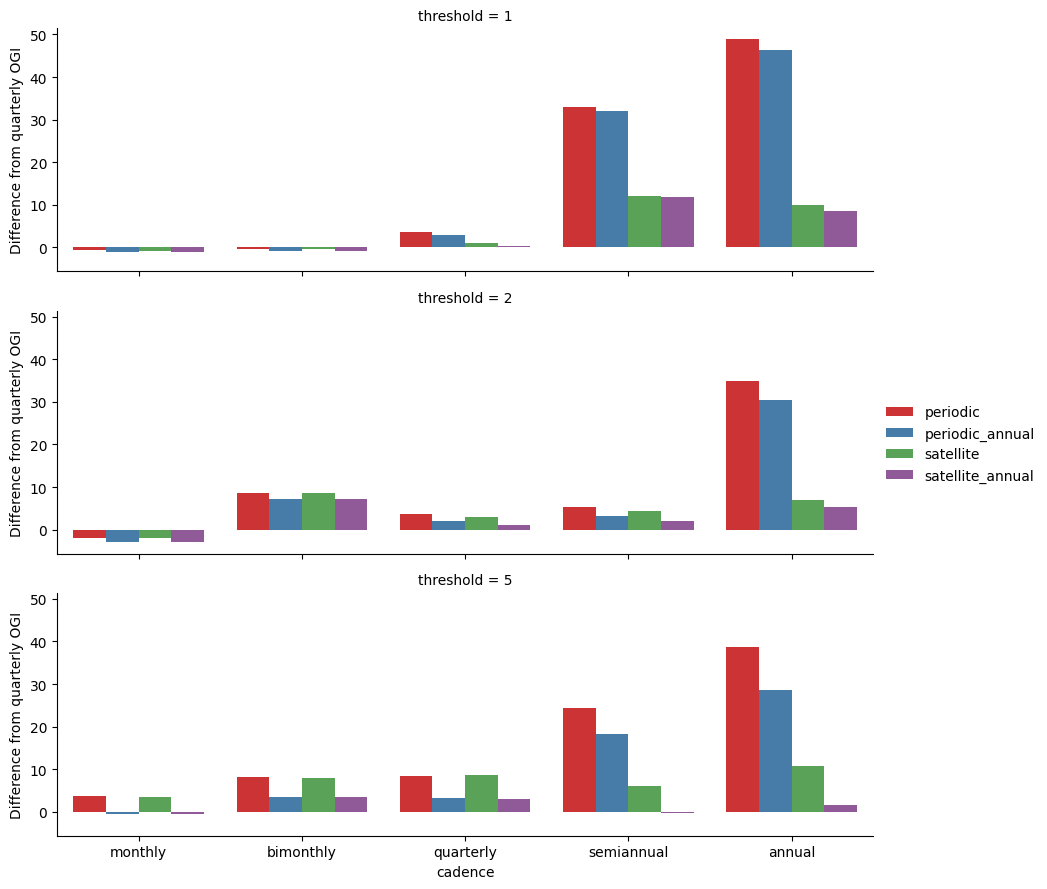

In [21]:
g = sns.FacetGrid(ratioed_results[ratioed_results['program'] != 'Null'], row = "threshold",  aspect = 3, height =3, )
g.map_dataframe(sns.barplot,  x = 'cadence', y = 'val',  hue = 'program',palette='Set1' ).add_legend().set(ylabel='Difference from quarterly OGI')

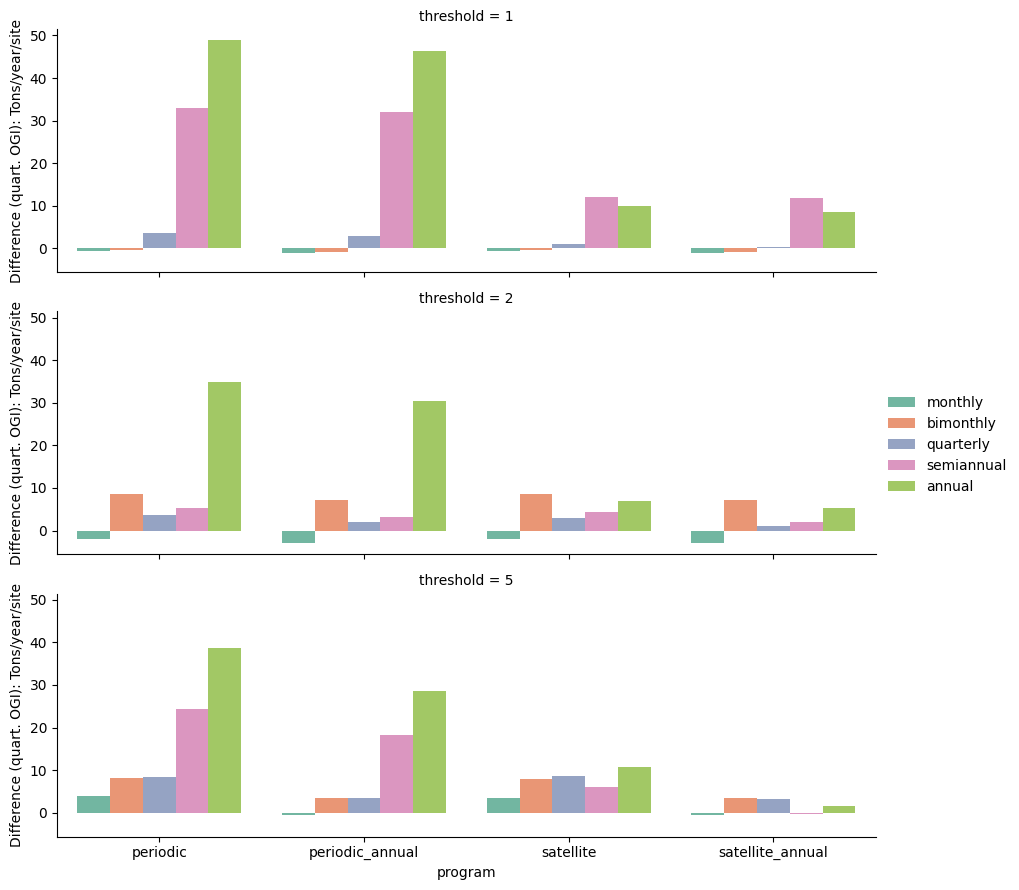

In [22]:
g = sns.FacetGrid(ratioed_results[ratioed_results['program'] != 'Null'], row = "threshold",  aspect = 3, height =3, )
g.map_dataframe(sns.barplot,  x = 'program', y = 'val',  hue = 'cadence',palette='Set2' ).add_legend().set(ylabel='Difference (quart. OGI): Tons/year/site')

Okay - check something - 

In [6]:
from scipy.special import erf #v1.15.2
import numpy as np

points = np.logspace(-3, 1, 100)  # emission rates
probs = 0.5 + 0.5 * np.array([erf((np.log(f) - np.log(0.02)) / (0.8 * np.sqrt(2))) for f in points])
# print(probs)

This is what UT has in their code to do the probaiblity codes: 
Okay, I figured it out = they either define the detection probabilities in a loaded JSON file, or they define something like upper and lower detection ranges and calculate the probability curve from those. that second option is confusing, and I wasn't able to follow it all the way through. 

In [26]:
pts = np.array([(0.25*1), 1]) * 1000 / (1 * 3600)
prob_curve = 0.5 + 0.5 * np.array([erf((np.log(f) - np.log(0.02)) / (0.8 * np.sqrt(2))) for f in pts])
print(prob_curve)

[0.94014518 0.99949703]


In [20]:
import json

with open('API_LDAR_setup/Aerial_epa2023_1.json') as f:
    check_ldar = json.load(f)
print(check_ldar)

{'type': 'site_survey', 'time': 'None', 'survey_interval': 91, 'sites_per_day': 1000, 'site_cost': 0, 'dispatch_object': 'None', 'site_queue': [], 'ophrs': {'begin': 8, 'end': 17}, 'dispatch_threshold': 'None', 'sensitivity': 0.001, 'detection_probability_points': [[0.07, 0.105, 0.14, 0.21, 0.28]], 'detection_probabilities': [0, 0.25, 0.5, 0.75, 1], 'detection_variables': {'flux': 'mean'}, 'op_envelope': 'None'}


In [21]:
print(0.0166 * 0.25)

0.00415


Okay - June 17 2025 - Ran the RTI code that we had; 

In [14]:
import json
with open('RTI_Run_Results/realization12.json') as f:
    runresults = json.load(f)

cm
ogi
plane
plane2
no LDAR


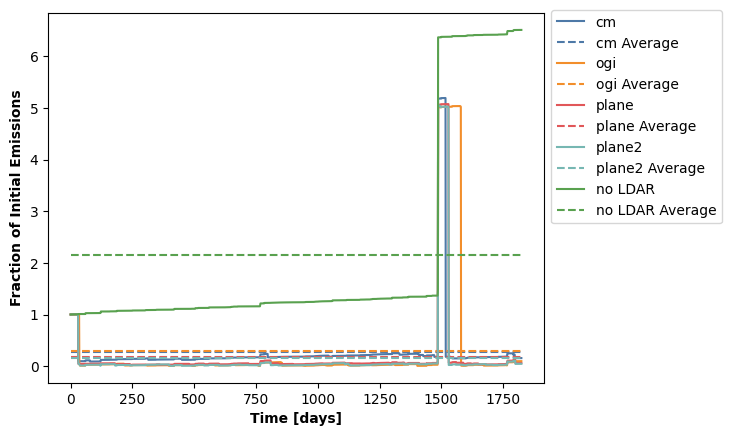

In [15]:
fig = plt.figure()
ax = fig.add_subplot(111)
counter = -1
 
for i in runresults.keys():
    lab = i #set the legend 
    #skip time and also set null to no LDAR
    if i.lower() == "null":
        lab = "no LDAR"
    if i.lower() == "time":
        break
    counter += 1
    print(lab)
    ax.plot(np.array(range(0,runresults['time']['n_timesteps'])), 
            np.array(runresults[i]['emission timeseries']) / runresults["Null"]['emission timeseries'][0], 
            label=lab, color=color_set[counter])
    
    avg_emissions = np.mean(np.array(runresults[i]['emission timeseries'])  / runresults["Null"]['emission timeseries'][0])
    ax.plot([0,runresults['time']['n_timesteps']],np.array([avg_emissions, avg_emissions]), '--', label = lab + ' Average', color = color_set[counter])


plt.xlabel('Time [days]', fontweight = 'bold')
plt.ylabel('Fraction of Initial Emissions', fontweight = 'bold')
plt.legend(loc = 'center left', bbox_to_anchor=(1, 0.72))